# Round 3 — Products, Relationships & Conclusions

This notebook explains each instrument, quantifies the relationships between them, and draws trading conclusions from the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'axes.labelsize': 10, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.2, 'grid.linewidth': 0.6,
})

DATA_DIR = Path('../../data/ROUND_3')
DAY_COLORS = {0: '#1b4f8f', 1: '#f28e2b', 2: '#b02a37'}
STRIKES    = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
UNDERLYING = 'VELVETFRUIT_EXTRACT'

prices = pd.concat([
    pd.read_csv(DATA_DIR / f'prices_round_3_day_{d}.csv', sep=';').assign(day=d)
    for d in (0, 1, 2)
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(DATA_DIR / f'trades_round_3_day_{d}.csv', sep=';').assign(day=d)
    for d in (0, 1, 2)
], ignore_index=True)
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

def day_legend(ax, **kw):
    ax.legend(handles=[Line2D([0],[0], color=c, lw=2.5, label=f'Day {d}') for d,c in DAY_COLORS.items()],
              frameon=False, **kw)

---
## Part 1 — What are the products?

Round 3 contains **3 instrument types**:

| Instrument | Type | Typical mid | Notes |
|---|---|---|---|
| `VELVETFRUIT_EXTRACT` | **Underlying spot** | ~5 250 | Mean-reverting, σ ≈ 14 ticks/day |
| `HYDROGEL_PACK` | **Independent spot** | ~10 000 | No mechanical link to VELVET |
| `VEV_K` (10 strikes) | **European call options** on VELVET | 0.5 – 1 250 | Strike K; expire end of round |

The **VEV options** follow the payoff:  `C = max(S − K, 0)`  at expiry, so the mid-price today reflects *intrinsic value + time value (extrinsic)*.

### Strike ladder & moneyness

With VELVET ≈ 5 250, the strikes split into three zones:

```
Deep ITM ←─────────────────────────────────→ Deep OTM
 VEV_4000  VEV_4500  VEV_5000  VEV_5100  VEV_5200  VEV_5300  VEV_5400  VEV_5500  VEV_6000  VEV_6500
  Δ≈1        Δ≈1      Δ≈0.9     Δ≈0.8     Δ≈0.7     Δ≈0.5     Δ≈0.3     Δ≈0.2     Δ≈0        Δ≈0
```

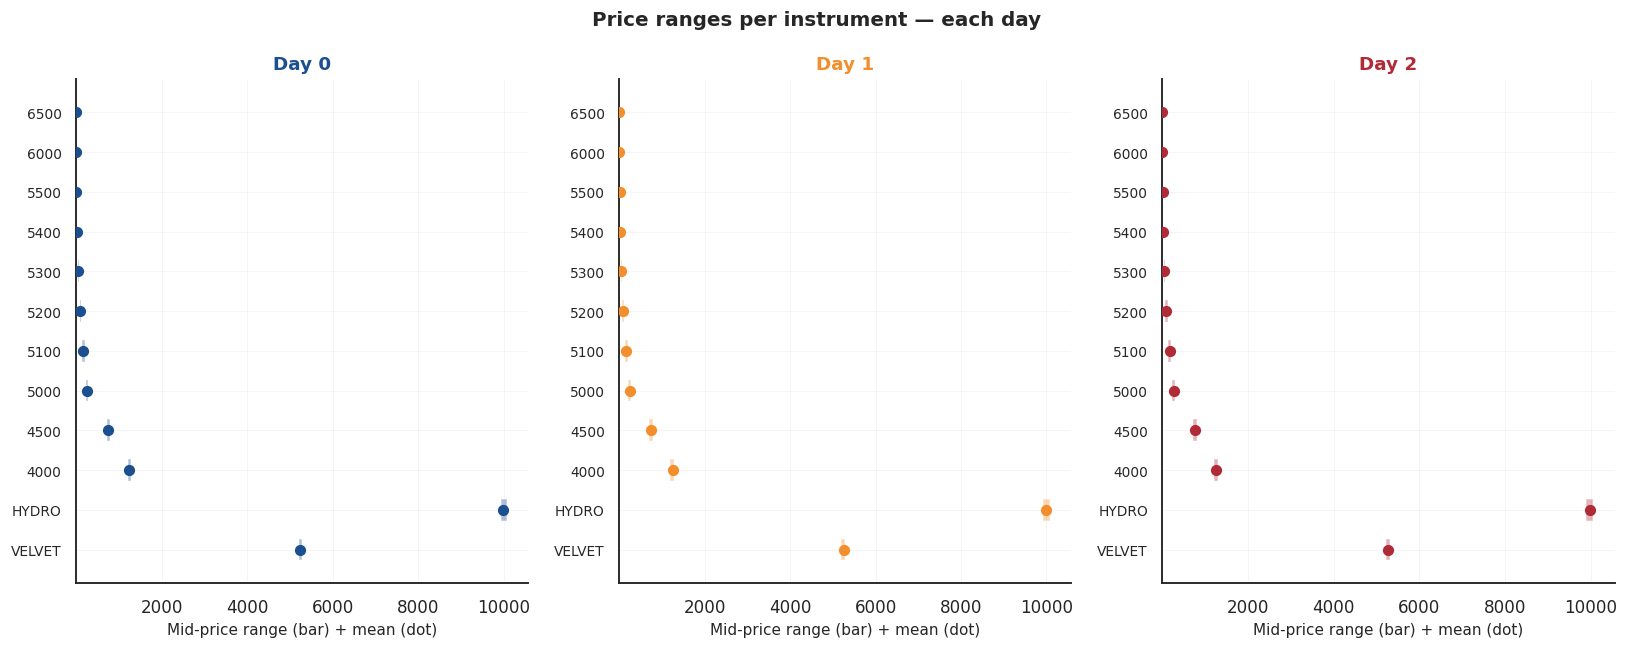

In [2]:
# Figure: price range of every instrument, coloured by day
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)
all_products = [UNDERLYING, 'HYDROGEL_PACK'] + [f'VEV_{k}' for k in STRIKES]
short_names  = ['VELVET', 'HYDRO'] + [str(k) for k in STRIKES]

for ax, d in zip(axes, (0, 1, 2)):
    df = prices[prices['day']==d]
    stats = df.groupby('product')['mid_price'].agg(['mean','min','max']).reindex(all_products)
    y = np.arange(len(stats))
    ax.barh(y, stats['max']-stats['min'], left=stats['min'],
            color=DAY_COLORS[d], alpha=0.35, height=0.55)
    ax.scatter(stats['mean'], y, color=DAY_COLORS[d], s=40, zorder=5)
    ax.set_yticks(y)
    ax.set_yticklabels(short_names, fontsize=9)
    ax.set_xlabel('Mid-price range (bar) + mean (dot)')
    ax.set_title(f'Day {d}', color=DAY_COLORS[d])
fig.suptitle('Price ranges per instrument — each day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2 — VELVETFRUIT_EXTRACT (the underlying)

**Behaviour:** mean-reverting around ~5 250 with tight bid-ask of exactly **5 ticks** every day. Short-term autocorrelation suggests market makers quote a stable range. No structural drift across the 3 days.

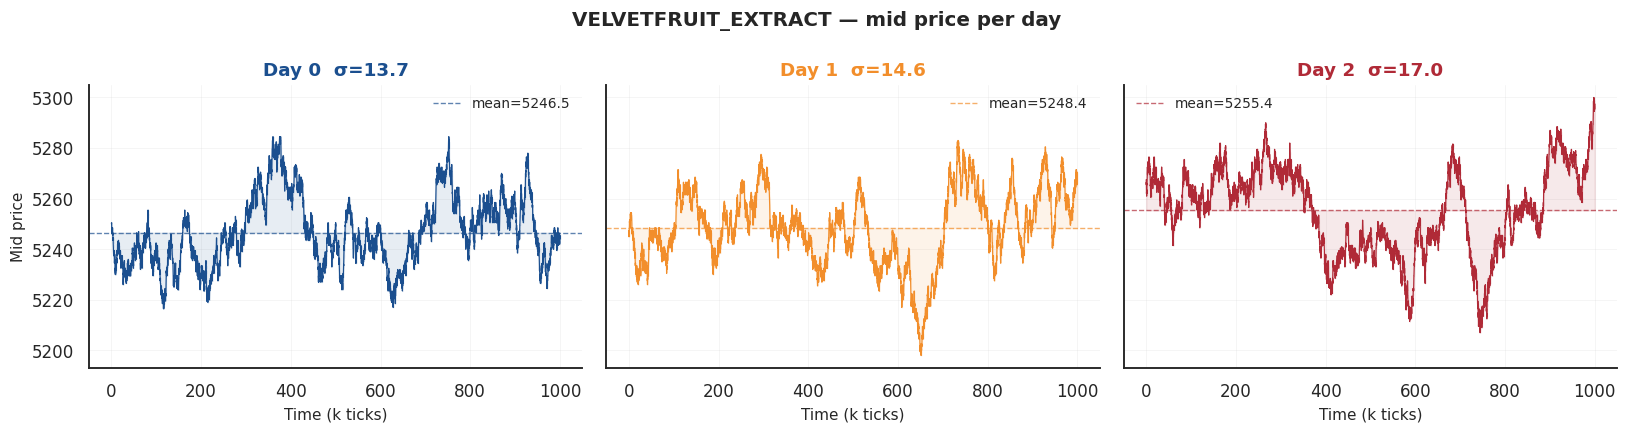

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, d in zip(axes, (0, 1, 2)):
    sub = prices[(prices['product']==UNDERLYING) & (prices['day']==d)]
    mid = sub['mid_price'].values
    t   = sub['timestamp'].values / 1000
    ax.plot(t, mid, color=DAY_COLORS[d], lw=0.8)
    ax.fill_between(t, mid, mid.mean(), color=DAY_COLORS[d], alpha=0.10)
    ax.axhline(mid.mean(), color=DAY_COLORS[d], ls='--', lw=0.9, alpha=0.7, label=f'mean={mid.mean():.1f}')
    ax.set_title(f'Day {d}  σ={mid.std():.1f}', color=DAY_COLORS[d])
    ax.set_xlabel('Time (k ticks)')
    if d==0: ax.set_ylabel('Mid price')
    ax.legend(frameon=False, fontsize=9)
fig.suptitle('VELVETFRUIT_EXTRACT — mid price per day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — HYDROGEL_PACK (the independent instrument)

**Return correlation with VELVET: ≈ 0.01 (effectively zero).** These two instruments have no direct price link — they move from independent information flows.

The ratio `HYDROGEL / VELVET ≈ 1.90` is stable (std ≈ 0.008) but that's just a numerical coincidence from their absolute price levels — not a synthetic link. There is **no exploitable pair-trade** between them from the data alone.

Bid-ask spread is 16 ticks (vs 5 for VELVET) — a wider, thinner market.

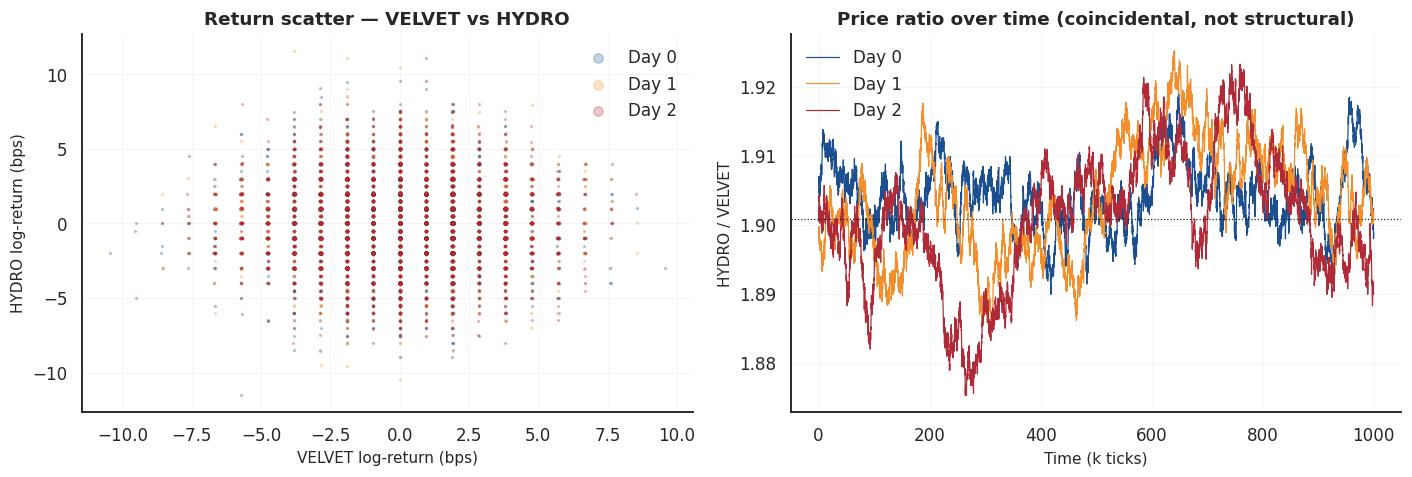

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: scatter of tick returns
ax = axes[0]
for d in (0, 1, 2):
    df = prices[prices['day']==d]
    v = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    h = df[df['product']=='HYDROGEL_PACK'].set_index('timestamp')['mid_price']
    m = pd.concat({'V':v,'H':h},axis=1).dropna()
    rv = np.log(m['V']).diff().dropna()
    rh = np.log(m['H']).diff().dropna()
    b  = pd.concat({'V':rv,'H':rh},axis=1).dropna()
    ax.scatter(b['V']*1e4, b['H']*1e4, s=1.5, color=DAY_COLORS[d], alpha=0.25, label=f'Day {d}')
ax.set_xlabel('VELVET log-return (bps)')
ax.set_ylabel('HYDRO log-return (bps)')
ax.set_title('Return scatter — VELVET vs HYDRO')
ax.legend(frameon=False, markerscale=5)

# Right: price/price ratio over time
ax = axes[1]
for d in (0, 1, 2):
    df = prices[prices['day']==d]
    v = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    h = df[df['product']=='HYDROGEL_PACK'].set_index('timestamp')['mid_price']
    m = pd.concat({'V':v,'H':h},axis=1).dropna()
    ratio = m['H'] / m['V']
    ax.plot(ratio.index/1000, ratio.values, color=DAY_COLORS[d], lw=0.8, label=f'Day {d}')
ax.axhline(ratio.mean(), color='k', ls=':', lw=0.8)
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('HYDRO / VELVET')
ax.set_title('Price ratio over time (coincidental, not structural)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Part 4 — The VEV Call Options

### What they are

`VEV_K` is a **European-style call option** on VELVETFRUIT_EXTRACT with strike `K`. Their theoretical price is:

$$C = \underbrace{\max(S - K,\; 0)}_{\text{intrinsic}} + \underbrace{\text{TV}}_{\text{extrinsic / time value}}$$

Time value decays to zero at expiry, so options bought at a premium over intrinsic lose that premium as the round progresses.

### Key zones in the ladder

| Zone | Strikes | Extrinsic | Spread | Behaviour |
|---|---|---|---|---|
| Deep ITM | 4000, 4500 | ≈ 0 | 16–21 ticks | Tracks underlying 1-for-1; wide spread |
| Near/ATM | 5000–5300 | 3–51 ticks | 2–6 ticks | Max time-value; tightest spreads relative to premium |
| OTM | 5400, 5500 | 6–18 ticks | 1 tick | Small extrinsic, cheapest to trade |
| Dead OTM | 6000, 6500 | 0.5 (floor) | 1 tick | Zero real value, minimum-quoted |

### Time decay across days

Extrinsic value falls monotonically Day 0 → Day 2 — exactly what theta-decay looks like.

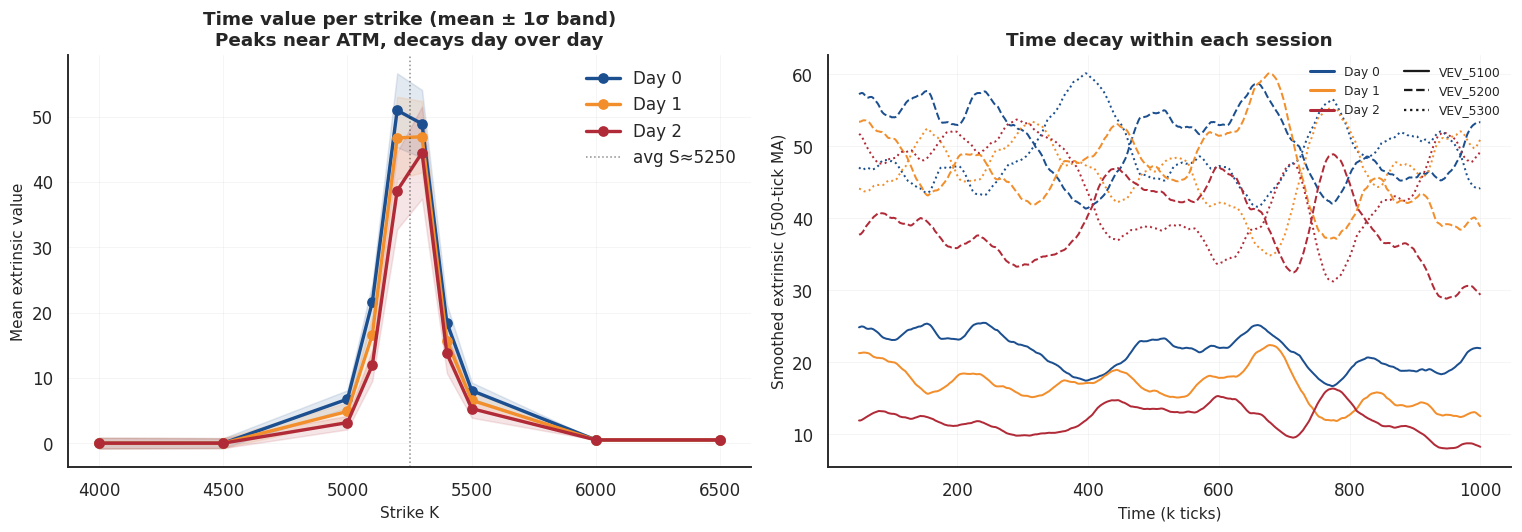

In [5]:
# Compute mean extrinsic per strike per day
ext_data = {d: {} for d in (0,1,2)}
for d in (0,1,2):
    df  = prices[prices['day']==d]
    und = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    for k in STRIKES:
        opt = df[df['product']==f'VEV_{k}'].set_index('timestamp')['mid_price']
        m   = pd.concat({'S':und,'C':opt},axis=1).dropna()
        ext = m['C'] - np.maximum(m['S']-k, 0)
        ext_data[d][k] = (ext.mean(), ext.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: extrinsic vs strike per day
ax = axes[0]
for d in (0,1,2):
    means = [ext_data[d][k][0] for k in STRIKES]
    stds  = [ext_data[d][k][1] for k in STRIKES]
    ax.plot(STRIKES, means, color=DAY_COLORS[d], lw=2.2, marker='o', label=f'Day {d}')
    ax.fill_between(STRIKES,
                    np.array(means)-np.array(stds),
                    np.array(means)+np.array(stds),
                    color=DAY_COLORS[d], alpha=0.12)
avg_S = prices[prices['product']==UNDERLYING]['mid_price'].mean()
ax.axvline(avg_S, color='k', ls=':', lw=1, alpha=0.5, label=f'avg S≈{avg_S:.0f}')
ax.set_xlabel('Strike K')
ax.set_ylabel('Mean extrinsic value')
ax.set_title('Time value per strike (mean ± 1σ band)\nPeaks near ATM, decays day over day')
ax.legend(frameon=False)

# Right: extrinsic over time for 3 interesting strikes
ax = axes[1]
focus = [5100, 5200, 5300]
focus_styles = ['-', '--', ':']
for d in (0,1,2):
    df  = prices[prices['day']==d]
    und = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    for k, ls in zip(focus, focus_styles):
        opt = df[df['product']==f'VEV_{k}'].set_index('timestamp')['mid_price']
        m   = pd.concat({'S':und,'C':opt},axis=1).dropna()
        ext = (m['C'] - np.maximum(m['S']-k, 0)).rolling(500).mean()
        label = f'VEV_{k} d{d}' if d==0 else None
        ax.plot(m.index/1000, ext.values, color=DAY_COLORS[d], ls=ls, lw=1.3, label=f'VEV_{k}' if d==0 else None)

# Custom legend
leg1 = [Line2D([0],[0], color=DAY_COLORS[d], lw=2, label=f'Day {d}') for d in (0,1,2)]
leg2 = [Line2D([0],[0], color='k', ls=ls, lw=1.5, label=f'VEV_{k}') for k,ls in zip(focus, focus_styles)]
ax.legend(handles=leg1+leg2, frameon=False, fontsize=8, ncol=2)
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('Smoothed extrinsic (500-tick MA)')
ax.set_title('Time decay within each session')
plt.tight_layout()
plt.show()

### Option–underlying co-movement (delta)

The effective **delta** of each VEV option (sensitivity to moves in the underlying) decreases as the strike moves OTM. Deep-ITM options move almost tick-for-tick with VELVET; OTM options barely budge.

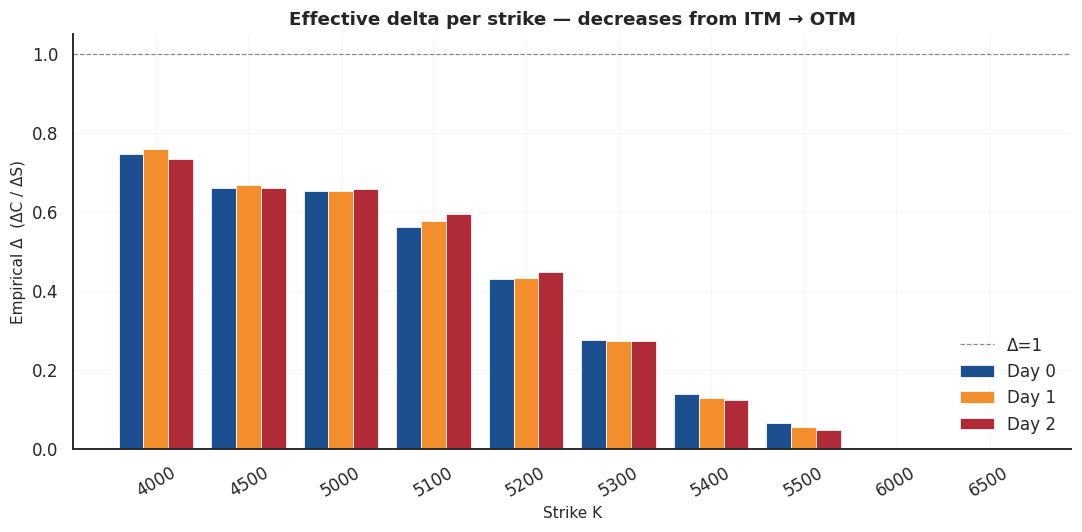

In [6]:
# Compute empirical delta: regress ΔC on ΔS tick-by-tick
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.27
x = np.arange(len(STRIKES))
for i, d in enumerate((0,1,2)):
    df  = prices[prices['day']==d]
    und = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    dS  = und.diff().dropna()
    deltas = []
    for k in STRIKES:
        opt = df[df['product']==f'VEV_{k}'].set_index('timestamp')['mid_price']
        m   = pd.concat({'dS':dS,'C':opt},axis=1).dropna()
        dC  = m['C'].diff().dropna()
        b   = pd.concat({'dS':m['dS'].iloc[1:],'dC':dC},axis=1).dropna()
        if len(b) > 10 and b['dS'].std() > 0:
            delta = np.cov(b['dS'], b['dC'])[0,1] / np.var(b['dS'])
        else:
            delta = np.nan
        deltas.append(delta)
    ax.bar(x + (i-1)*width, deltas, width=width, color=DAY_COLORS[d],
           label=f'Day {d}', edgecolor='white', linewidth=0.5)

ax.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5, label='Δ=1')
ax.axhline(0.0, color='k', lw=0.5, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in STRIKES], rotation=30)
ax.set_xlabel('Strike K')
ax.set_ylabel('Empirical Δ  (ΔC / ΔS)')
ax.set_title('Effective delta per strike — decreases from ITM → OTM')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Part 5 — Are VEVs fairly priced? (No-arbitrage check)

For deep-ITM options the **lower bound** is `max(S−K, 0)`. Any time the mid drops *below* intrinsic we have a textbook arbitrage: buy the call, exercise immediately.

Below we plot `C − intrinsic` (must be ≥ 0 at all times). Negative values signal mispricings that can be traded.

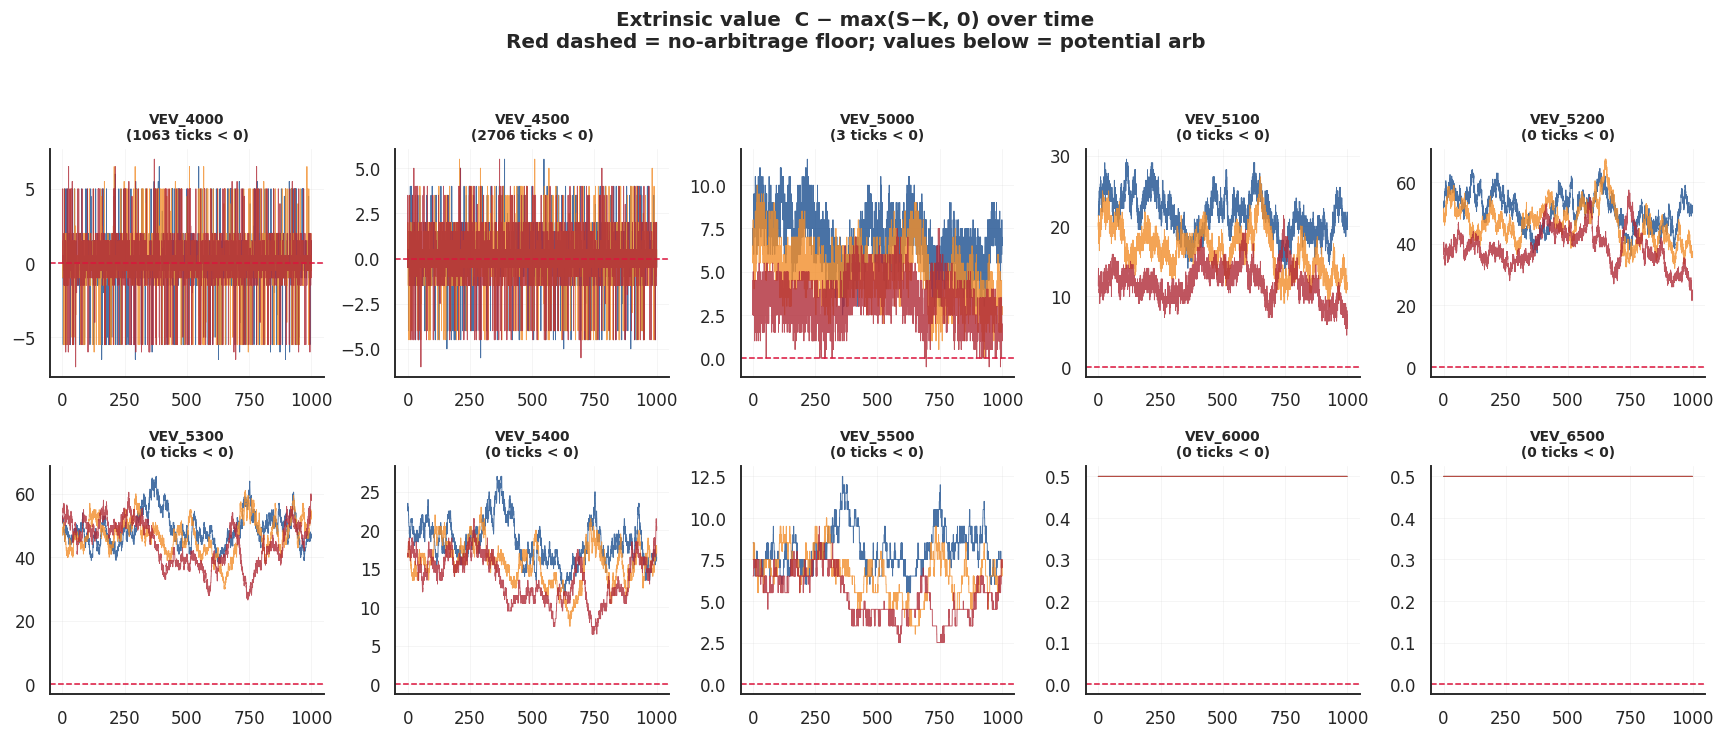

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5), sharey=False)
for idx, k in enumerate(STRIKES):
    ax = axes[idx//5][idx%5]
    for d in (0,1,2):
        df  = prices[prices['day']==d]
        und = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
        opt = df[df['product']==f'VEV_{k}'].set_index('timestamp')['mid_price']
        m   = pd.concat({'S':und,'C':opt},axis=1).dropna()
        ext = m['C'] - np.maximum(m['S']-k, 0)
        ax.plot(m.index/1000, ext.values, color=DAY_COLORS[d], lw=0.6, alpha=0.8)
    ax.axhline(0, color='crimson', lw=1.0, ls='--')
    n_arb = (ext < 0).sum()
    ax.set_title(f'VEV_{k}\n({n_arb} ticks < 0)', fontsize=9)
    ax.set_xlabel('')
fig.suptitle('Extrinsic value  C − max(S−K, 0) over time\n'
             'Red dashed = no-arbitrage floor; values below = potential arb', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 6 — Spread as a fraction of option value

Absolute spread means little on its own — what matters is **spread / mid** (the round-trip cost as a percentage of the option's value). OTM options look cheap in absolute spread, but may be expensive per-dollar-of-option.

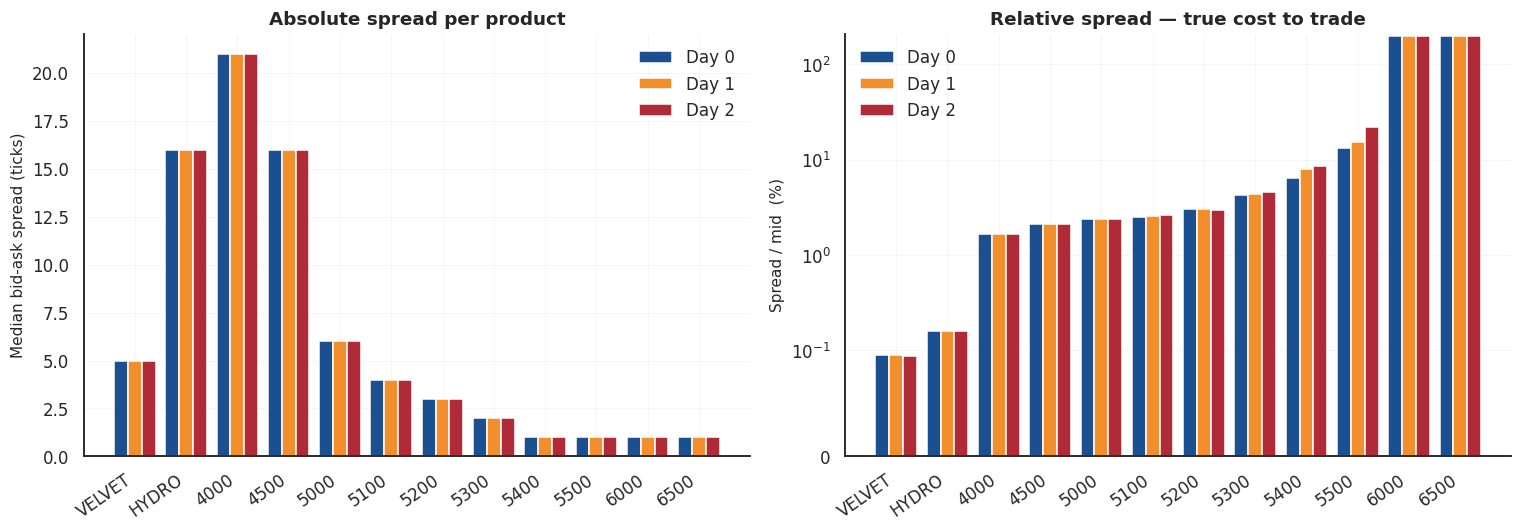

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_p = [UNDERLYING, 'HYDROGEL_PACK'] + [f'VEV_{k}' for k in STRIKES]
short = ['VELVET', 'HYDRO'] + [str(k) for k in STRIKES]

# Absolute spread
ax = axes[0]
sp_abs = prices.groupby(['product','day'])['spread'].median().unstack('day').reindex(all_p)
x = np.arange(len(sp_abs))
for i,d in enumerate((0,1,2)):
    ax.bar(x + (i-1)*0.27, sp_abs[d], width=0.27, color=DAY_COLORS[d], label=f'Day {d}', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(short, rotation=35, ha='right')
ax.set_ylabel('Median bid-ask spread (ticks)')
ax.set_title('Absolute spread per product')
ax.legend(frameon=False)

# Relative spread (% of mid)
ax = axes[1]
prices['rel_spread'] = prices['spread'] / prices['mid_price'] * 100
sp_rel = prices.groupby(['product','day'])['rel_spread'].median().unstack('day').reindex(all_p)
for i,d in enumerate((0,1,2)):
    ax.bar(x + (i-1)*0.27, sp_rel[d], width=0.27, color=DAY_COLORS[d], label=f'Day {d}', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(short, rotation=35, ha='right')
ax.set_ylabel('Spread / mid  (%)')
ax.set_title('Relative spread — true cost to trade')
ax.set_yscale('symlog', linthresh=0.1)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Part 7 — Market structure summary diagram

One visual that shows all relationships at a glance.

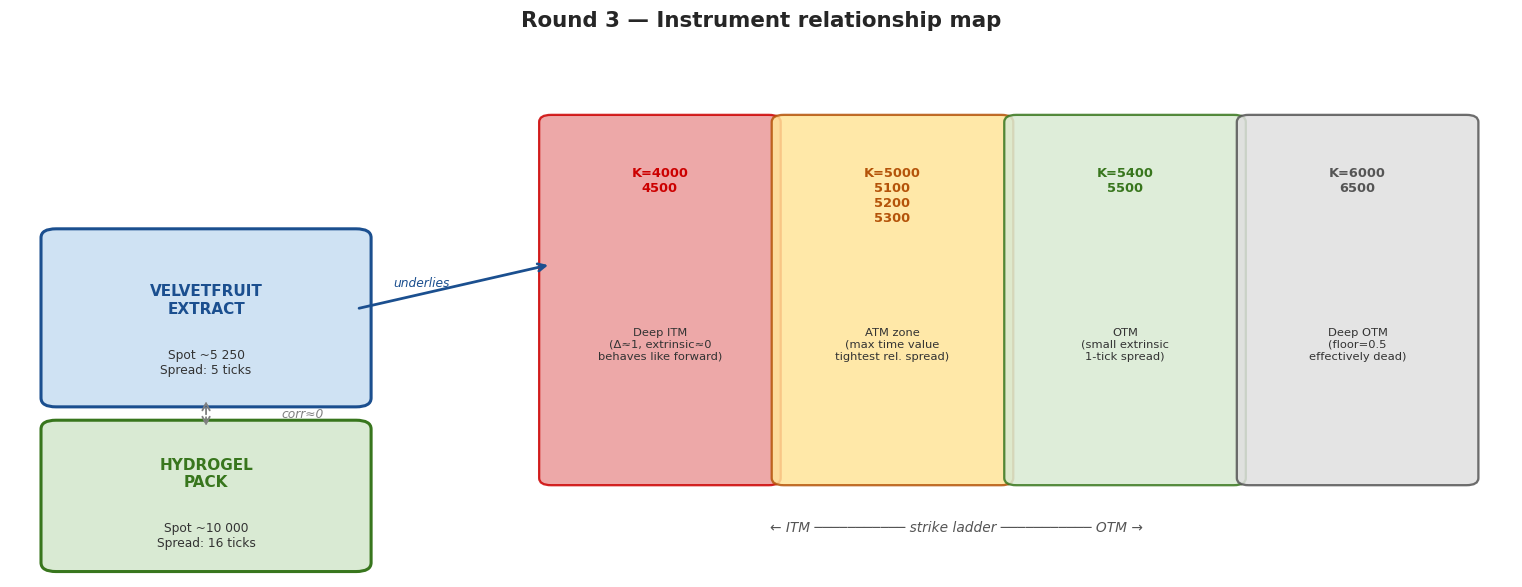

In [9]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect('auto')
ax.axis('off')

# VELVET box
velvet_box = mpatches.FancyBboxPatch((0.3, 2.0), 2.0, 1.8,
    boxstyle='round,pad=0.1', facecolor='#cfe2f3', edgecolor='#1b4f8f', lw=2)
ax.add_patch(velvet_box)
ax.text(1.3, 3.1, 'VELVETFRUIT\nEXTRACT', ha='center', va='center', fontsize=10, fontweight='bold', color='#1b4f8f')
ax.text(1.3, 2.4, 'Spot ~5 250\nSpread: 5 ticks', ha='center', va='center', fontsize=8, color='#333')

# HYDRO box
hydro_box = mpatches.FancyBboxPatch((0.3, 0.15), 2.0, 1.5,
    boxstyle='round,pad=0.1', facecolor='#d9ead3', edgecolor='#38761d', lw=2)
ax.add_patch(hydro_box)
ax.text(1.3, 1.15, 'HYDROGEL\nPACK', ha='center', va='center', fontsize=10, fontweight='bold', color='#38761d')
ax.text(1.3, 0.45, 'Spot ~10 000\nSpread: 16 ticks', ha='center', va='center', fontsize=8, color='#333')

# NO LINK indicator
ax.annotate('', xy=(1.3, 2.0), xytext=(1.3, 1.65),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2, linestyle='dashed'))
ax.text(1.8, 1.82, 'corr≈0', ha='left', va='center', fontsize=8, color='gray', style='italic')

# Arrow to options
ax.annotate('', xy=(3.6, 3.5), xytext=(2.3, 3.0),
            arrowprops=dict(arrowstyle='->', color='#1b4f8f', lw=1.8))
ax.text(2.55, 3.25, 'underlies', fontsize=8, color='#1b4f8f', style='italic')

# Options ladder
zone_info = [
    ('4000\n4500', 'Deep ITM\n(Δ≈1, extrinsic≈0\nbehaves like forward)', '#ea9999', '#cc0000'),
    ('5000\n5100\n5200\n5300', 'ATM zone\n(max time value\ntightest rel. spread)', '#ffe599', '#b45309'),
    ('5400\n5500', 'OTM\n(small extrinsic\n1-tick spread)', '#d9ead3', '#38761d'),
    ('6000\n6500', 'Deep OTM\n(floor=0.5\neffectively dead)', '#e0e0e0', '#555'),
]
xstart = 3.6
for strikes_label, zone_label, facecolor, edgecolor in zone_info:
    box = mpatches.FancyBboxPatch((xstart, 1.1), 1.45, 4.0,
        boxstyle='round,pad=0.08', facecolor=facecolor, edgecolor=edgecolor, lw=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(xstart+0.725, 4.6, f'K={strikes_label}', ha='center', va='top', fontsize=8.5, fontweight='bold', color=edgecolor)
    ax.text(xstart+0.725, 2.6, zone_label, ha='center', va='center', fontsize=7.5, color='#333')
    xstart += 1.55

ax.text(6.3, 0.5, '← ITM ─────────── strike ladder ─────────── OTM →', ha='center', fontsize=9, color='#555', style='italic')
ax.set_title('Round 3 — Instrument relationship map', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Part 8 — Key Conclusions

### 1. Product taxonomy
- **VELVETFRUIT_EXTRACT** — mean-reverting spot with tight 5-tick spread. The foundational instrument to trade.
- **HYDROGEL_PACK** — fully independent. No signal from VELVET. Trade on its own mean-reversion.
- **VEV options** — 10 European calls expiring at the end of Round 3.

### 2. Option market structure
- Deep-ITM calls (4000, 4500) are **delta-1 proxies** for VELVET — pure directional exposure, no extrinsic risk, but expensive to trade (16–21 tick spread).
- ATM zone (5000–5300) carries **the most time value** and tightest *relative* spread. This is where options are most interesting.
- OTM calls (5400, 5500) are cheap in spread (1 tick) but carry small and decaying extrinsic.
- Deep-OTM (6000, 6500) are floor-valued at 0.5 — treat as worthless.

### 3. Time decay is real and measurable
Extrinsic value declines Day 0 → Day 1 → Day 2 across every strike. Options sellers collect theta; buyers pay for gamma.

### 4. Potential mispricings
Deep-ITM calls occasionally print **below intrinsic** (extrinsic < 0). This is a risk-free arb: buy the call at the ask (< intrinsic), and it must converge upward or can be exercised for immediate profit.

### 5. Spread cost reality check
- OTM options look cheap in ticks but have 10–50%+ relative spread → hard to profit from directional trades.
- ATM options (5200, 5300) have 2–3 tick spread on a 50–100 tick option → more tractable.
- VELVET at 5 ticks on a 5250 price = 0.1% round-trip — the tightest market in the round.

In [10]:
# Final summary table
rows = []
for p in [UNDERLYING, 'HYDROGEL_PACK'] + [f'VEV_{k}' for k in STRIKES]:
    sub = prices[prices['product']==p]
    rows.append({
        'Product': p,
        'Mid (avg)': sub['mid_price'].mean().round(1),
        'Spread (med)': sub['spread'].median(),
        'Spread %': (sub['spread']/sub['mid_price']).median().round(4)*100,
        'σ per day': sub.groupby('day')['mid_price'].std().mean().round(2),
    })
summary = pd.DataFrame(rows).set_index('Product')

# Colour the extrinsic column
ext_means = {}
for d in (0,1,2):
    df  = prices[prices['day']==d]
    und = df[df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    for k in STRIKES:
        opt = df[df['product']==f'VEV_{k}'].set_index('timestamp')['mid_price']
        m   = pd.concat({'S':und,'C':opt},axis=1).dropna()
        ext = (m['C'] - np.maximum(m['S']-k,0)).mean()
        ext_means.setdefault(f'VEV_{k}', []).append(ext)
summary['Extrinsic (avg D0)'] = pd.Series({f'VEV_{k}': ext_means[f'VEV_{k}'][0] for k in STRIKES}).round(2)
summary

,Mid (avg),Spread (med),Spread %,σ per day,Extrinsic (avg D0)
Product,,,,,
VELVETFRUIT_EXTRACT,5250.1,5.0,0.10,15.09,NaN
HYDROGEL_PACK,9990.8,16.0,0.16,31.52,NaN
VEV_4000,1250.1,21.0,1.68,15.11,0.01
VEV_4500,750.1,16.0,2.13,15.10,0.01
VEV_5000,255.0,6.0,2.39,14.08,6.75
VEV_5100,166.8,4.0,2.58,12.57,21.60
VEV_5200,95.5,3.0,3.05,9.44,50.96
VEV_5300,46.8,2.0,4.35,5.90,48.89
VEV_5400,16.0,1.0,8.00,2.82,18.47
